In [77]:
import re
import subprocess
from dataclasses import dataclass
from typing import Optional

@dataclass
class TimingEntry:
    time: float
    percent: float


@dataclass
class TimingRun:
    run_id: Optional[int]  # None = Average
    parts: list[TimingEntry]


def parse_timing_output(text: str) -> list[(int, (float, float), (float, float), (float, float))]:
    runs = []

    for line in text.strip().splitlines():
        run_match = re.match(r"Detailed Timing of Run (\d+):", line)
        avg_match = re.match(r"Average Time of the Runs:", line)
        total_match = re.match(r"Average time taken: ([\d.]+) seconds", line)

        if not run_match and not avg_match and not total_match:
            continue

        run_id = int(run_match.group(1)) if run_match else None

        pairs = re.findall(r"([\d.]+)\s*\(([\d.]+)\s*%\)", line)
        parts = [(float(time), float(perc)) for time, perc in pairs]

        avg_time = float(total_match.group(1)) if total_match else None
        runs.append((run_id, avg_time, parts))

    return runs


In [ ]:
from subprocess import TimeoutExpired

MAX_SECONDS = 10
STEP_SIZE = 50000000
MAX_NUMBER_COUNT = 1000000000
BIT_COUNTS_TO_TEST = [1, 2, 4, 8, 16]

timings = {}
for bits in BIT_COUNTS_TO_TEST:
    for numberCount in range(50000000, MAX_NUMBER_COUNT, STEP_SIZE):

        try:
            output = subprocess.check_output(["../problem_1", f"{numberCount} {bits}"], timeout=300)
            timings[(bits, numberCount)] = parse_timing_output(output.decode())
            print(f"{bits},{numberCount} done in {timings[(bits, numberCount)][len(timings[(bits, numberCount)]) - 1][1]:.2f}s")
            if timings[(bits, numberCount)][len(timings[(bits, numberCount)]) - 1][1] > 10:
                print(f"greater 10s -> next bits")
                break
        except TimeoutExpired as e:
            print(f"Timeout -> next bits")
            break

1,50000000 done in 0.73s
1,100000000 done in 1.39s
1,150000000 done in 2.08s
1,200000000 done in 2.77s
1,250000000 done in 4.00s


In [49]:
for bits, numberCount in timings:
    for run_id, avg, times in timings[(bits, numberCount)]:
        if run_id is not None: continue
        print(f"Bits: {bits}, Number Count: {numberCount}, Avg: {avg}, Timings: ", end="")
        print(", ".join({f"{time:.8f} ({perc:.8f}%)" for time, perc in times}))

Bits: 2, Number Count: 10000, Avg: None, Timings: 0.00006600 (51.48187081%), 0.00005860 (45.70999545%), 0.00000160 (1.24805944%)
Bits: 2, Number Count: 10000, Avg: 0.0, Timings: 
Bits: 2, Number Count: 50010000, Avg: None, Timings: 0.00000280 (0.00039310%), 0.20639200 (28.97593611%), 0.50588740 (71.02291267%)
Bits: 2, Number Count: 50010000, Avg: 0.0, Timings: 
Bits: 2, Number Count: 100010000, Avg: None, Timings: 0.96939720 (70.99309327%), 0.39607500 (29.00626227%), 0.00000380 (0.00027829%)
Bits: 2, Number Count: 100010000, Avg: 1.0, Timings: 
Bits: 2, Number Count: 150010000, Avg: None, Timings: 0.00000200 (0.00009630%), 1.48241840 (71.37808847%), 0.59442760 (28.62154559%)
Bits: 2, Number Count: 150010000, Avg: 2.0, Timings: 
Bits: 2, Number Count: 200010000, Avg: None, Timings: 0.00000260 (0.00009364%), 1.97988980 (71.31080224%), 0.79652640 (28.68893844%)
Bits: 2, Number Count: 200010000, Avg: 2.0, Timings: 
Bits: 2, Number Count: 250010000, Avg: None, Timings: 2.48885700 (71.244371

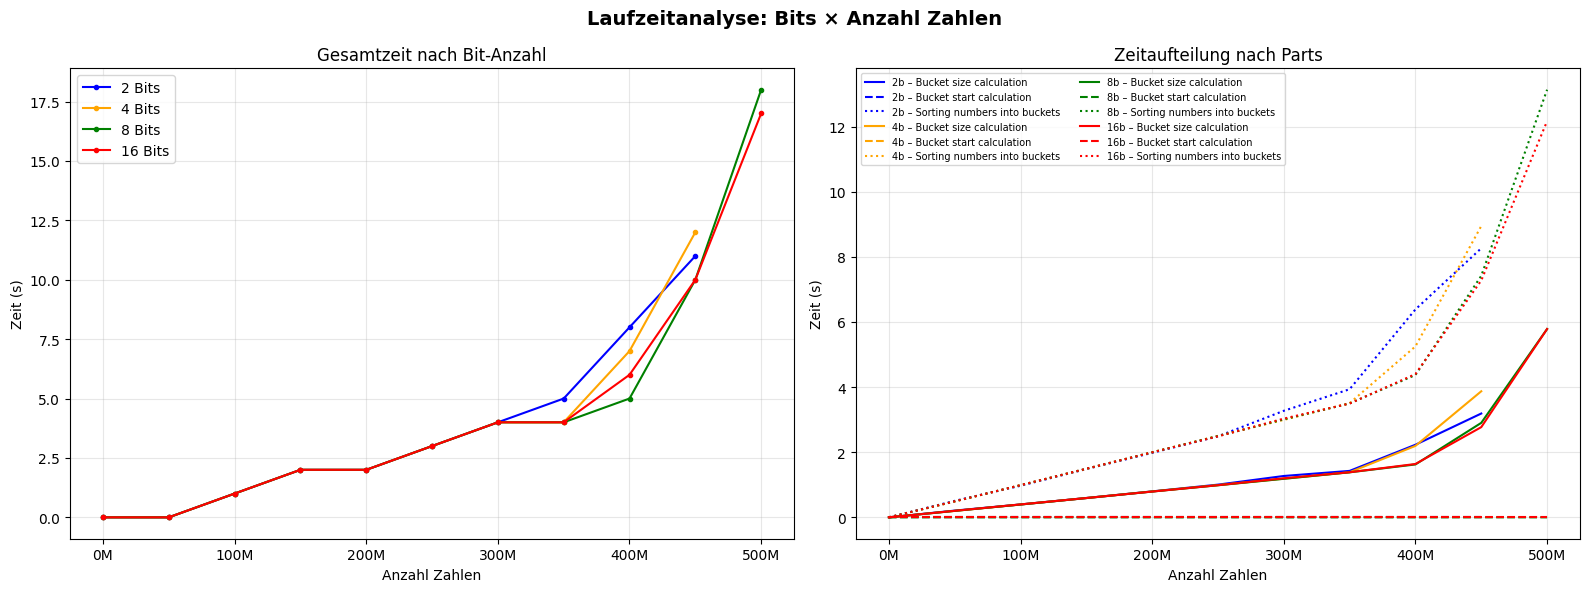

In [59]:
import matplotlib.pyplot as plt

colors = {2: 'blue', 4: 'orange', 8: 'green', 16: 'red'}
part_labels = ['Bucket size calculation', 'Bucket start calculation', 'Sorting numbers into buckets']
part_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


def get_avg_time(runs):
    """Aus der 'Average time taken:' Zeile"""
    return next((avg_time
                 for run_id, avg_time, parts in runs
                 if avg_time is not None), None)

def get_avg_parts(runs):
    """Aus der 'Average Time of the Runs:' Zeile"""
    return next((parts
                 for run_id, avg_time, parts in runs
                 if run_id is None and len(parts) > 0), None)


# --- Plot 1: Gesamtzeit (avg_time) pro Bit-Anzahl ---
ax1 = axes[0]
# --- Plot 1: Gesamtzeit ---
for bits in BIT_COUNTS_TO_TEST:
    xs, ys = [], []
    for numberCount in range(10000, MAX_NUMBER_COUNT, STEP_SIZE):
        result = timings.get((bits, numberCount))
        if result is None:
            continue
        avg_time = get_avg_time(result)
        if avg_time is not None:
            xs.append(numberCount)
            ys.append(avg_time)
    ax1.plot(xs, ys, label=f"{bits} Bits", color=colors[bits], marker='o', markersize=3)


ax1.set_title("Gesamtzeit nach Bit-Anzahl")
ax1.set_xlabel("Anzahl Zahlen")
ax1.set_ylabel("Zeit (s)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))

ax2 = axes[1]
# --- Plot 2: Parts ---
for bits in BIT_COUNTS_TO_TEST:
    xs = []
    part_times = [[], [], []]
    for numberCount in range(10000, MAX_NUMBER_COUNT, STEP_SIZE):
        result = timings.get((bits, numberCount))
        if result is None:
            continue
        parts = get_avg_parts(result)
        if parts:
            xs.append(numberCount)
            for i, (t, _) in enumerate(parts):
                part_times[i].append(t)

    for i, (pt, style) in enumerate(zip(part_times, part_styles)):
        ax2.plot(xs, pt, label=f"{bits}b – {part_labels[i]}",
                 color=colors[bits], linestyle=style, linewidth=1.5)

ax2.set_title("Zeitaufteilung nach Parts")
ax2.set_xlabel("Anzahl Zahlen")
ax2.set_ylabel("Zeit (s)")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))

plt.suptitle("Laufzeitanalyse: Bits × Anzahl Zahlen", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()